# BTC Time Series Model Development

In [1]:
## Imports
## Standard Lib

## 3rd Party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

## Custom Modules


## Data Cleaning 

In [2]:
df = pd.read_csv("../data/btc-time-series-data.csv")
df["event_date"] = pd.to_datetime(df["event_date"])
df = df.drop(columns=["market_cap_usd", "volume_usd"])

print(f"{'------'}\nData Dimensions\n{'------'}")
print(df.shape)

print(f"\n{'------'}\nNull Counts\n{'------'}")
print(df.isnull().sum())


------
Data Dimensions
------
(4881, 2)

------
Null Counts
------
event_date         0
close_price_usd    1
dtype: int64


## Data Visulization

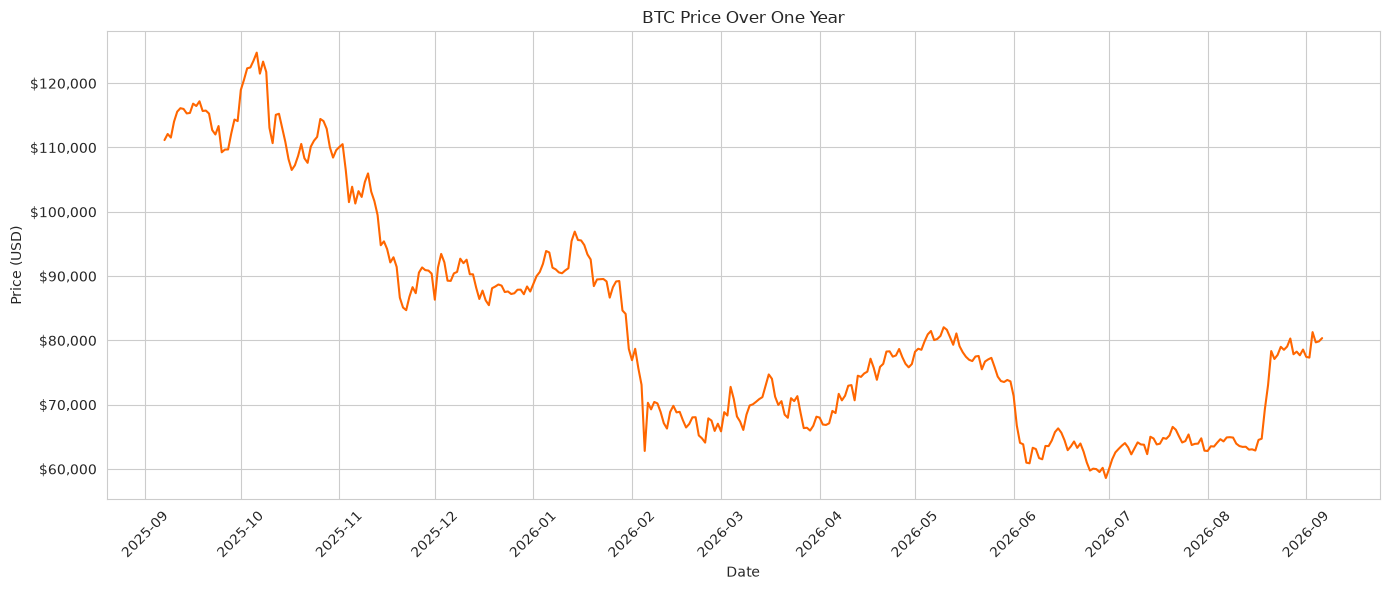

In [3]:
end_date = df["event_date"].max()
start_date = end_date - pd.DateOffset(years=1)
plot_df = df.loc[df["event_date"] >= start_date]

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(plot_df["event_date"], plot_df["close_price_usd"], color="#FF6600")
ax.set_title("BTC Price Over One Year")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Model Training 


In [4]:
## Data split cell.
# Chronological 75/25 split on the last year of daily close prices.
yoy_start = df["event_date"].max() - pd.DateOffset(years=1)
ts = (
    df.loc[df["event_date"] >= yoy_start]
    .dropna(subset=["close_price_usd"])
    .sort_values("event_date")
    .set_index("event_date")["close_price_usd"]
    .asfreq("D")
    .interpolate(method="time")
)

split_idx = int(len(ts) * 0.75)
train = ts.iloc[:split_idx]
valid = ts.iloc[split_idx:]

print(f"Full series: {len(ts)} days ({ts.index.min().date()} → {ts.index.max().date()})")
print(f"Train: {len(train)} days ({train.index.min().date()} → {train.index.max().date()})")
print(f"Valid: {len(valid)} days ({valid.index.min().date()} → {valid.index.max().date()})")


Full series: 365 days (2025-09-07 → 2026-09-06)
Train: 273 days (2025-09-07 → 2026-06-06)
Valid: 92 days (2026-06-07 → 2026-09-06)


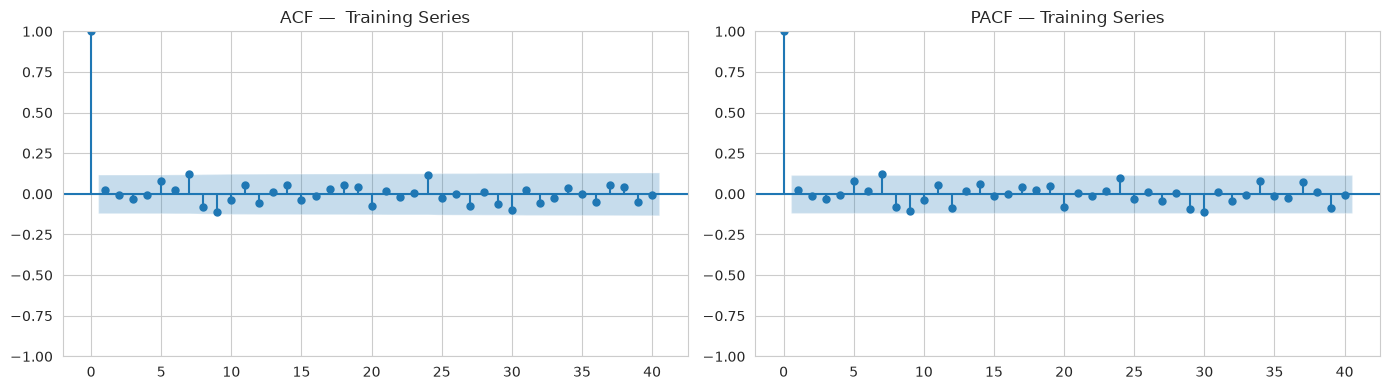

In [5]:
## ACF/ PACF cell.
# Inspect these plots to choose p (PACF) and q (ACF). Retrain after updating order.

train_diff = train.diff().dropna()

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_diff, ax=axes[0], lags=40)
plot_pacf(train_diff, ax=axes[1], lags=40, method="ywm")
axes[0].set_title("ACF —  Training Series")
axes[1].set_title("PACF — Training Series")
plt.tight_layout()
plt.show()


In [6]:
## Model training cell.
# Update p and q from the ACF/PACF plots, then re-run this cell to retrain.
# p, d, q = 1, 1, 1

p, d, q = 1, 0, 1


fitted_model = ARIMA(train_diff, order=(p, d, q)).fit()

print(f"ARIMA{p, d, q}")
print(fitted_model.summary())


ARIMA(1, 0, 1)
                               SARIMAX Results                                
Dep. Variable:        close_price_usd   No. Observations:                  272
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -2453.038
Date:                Fri, 11 Sep 2026   AIC                           4914.076
Time:                        09:20:42   BIC                           4928.499
Sample:                    09-08-2025   HQIC                          4919.866
                         - 06-06-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -184.8450    143.629     -1.287      0.198    -466.353      96.664
ar.L1         -0.1006      2.146     -0.047      0.963      -4.307       4.106
ma.L1          0.1242      2.152     

## Model Validation 

In [7]:
## Model forecast cell.
# Model is fit on price levels with d=1, so mean and CI are already in USD.
forecast = fitted_model.get_forecast(steps=5)

forecast_mean = forecast.predicted_mean
# Do not cumsum price-level forecasts or CI bounds (that stacks worst-case days).
forecast_mean = train.iloc[-1] + forecast_mean.cumsum()
# forecast_mean = train.iloc[-1] * np.exp(forecast.predicted_mean.cumsum())
forecast_mean.index = valid.index[: len(forecast_mean)]

forecast_ci = forecast.conf_int()
# forecast_ci = train.iloc[-1] + forecast_ci.cumsum()
forecast_ci.index = valid.index[: len(forecast_ci)]

print(forecast_mean.head())
print(forecast_ci.head())

### Forecasting Rules: 
# Horizon	       Usability
# 1–5 steps	       Most useful; tightest CI
# 5–14 steps	   Still usable, but CI widens noticeably
# 15–30 steps	   Marginal; forecast ≈ mean + slight trend
# 30+ steps	       Essentially useless for a linear model




event_date
2026-06-07 00:00:00+00:00    60680.183416
2026-06-08 00:00:00+00:00    60494.355398
2026-06-09 00:00:00+00:00    60309.609300
2026-06-10 00:00:00+00:00    60124.754386
2026-06-11 00:00:00+00:00    59939.910416
Freq: D, Name: predicted_mean, dtype: float64
                           lower close_price_usd  upper close_price_usd
event_date                                                             
2026-06-07 00:00:00+00:00           -4098.222507            3748.080810
2026-06-08 00:00:00+00:00           -4110.072666            3738.416630
2026-06-09 00:00:00+00:00           -4109.001801            3739.509605
2026-06-10 00:00:00+00:00           -4109.110729            3739.400900
2026-06-11 00:00:00+00:00           -4109.099785            3739.411846


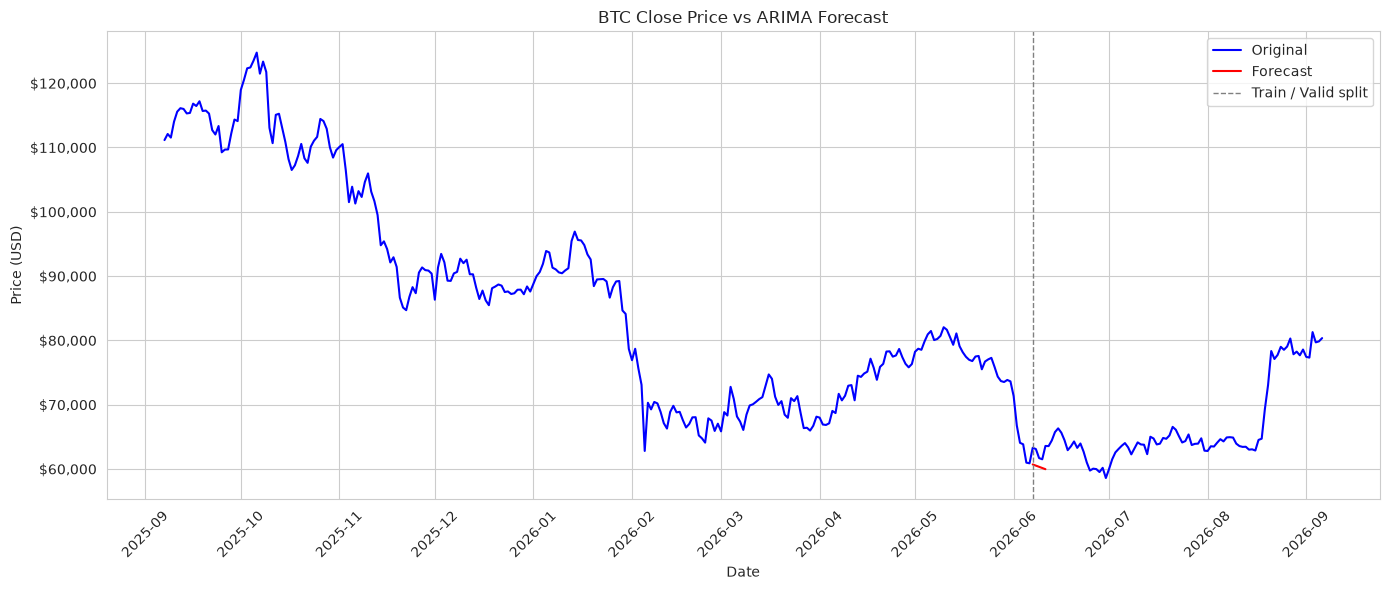

In [8]:
## Validation plot vs forecasted plot cell.
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts.index, ts.values, color="blue", label="Original")

ax.plot(forecast_mean.index, forecast_mean.values, color="red", label="Forecast")
ax.axvline(valid.index.min(), color="gray", linestyle="--", linewidth=1, label="Train / Valid split")
ax.set_title("BTC Close Price vs ARIMA Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [9]:
## Loss function cell.
y_true = valid.iloc[: len(forecast_mean)]
errors = y_true - forecast_mean
mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors ** 2))
mape = np.mean(np.abs(errors / y_true)) * 100

print(f"{'------'}\nValidation Loss\n{'------'}")
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"MAPE: {mape:.2f}%")




------
Validation Loss
------
MAE:  $2,299.89
RMSE: $2,454.21
MAPE: 3.66%


In [ ]:
## Full-series training cell.
# Retrain on the full series using the same (p, d, q).
ts_diff = ts.diff().dropna()
# full_model = ARIMA(ts_diff, order=(p, d, q)).fit()
# Fit on price levels so the CI is already in USD (no stacking worst-case days).
full_model = ARIMA(ts, order=(p, d, q)).fit()


In [ ]:
## Full-series forecast cell.
horizon = 5
full_forecast = full_model.get_forecast(steps=horizon)

# full_forecast_mean = ts.iloc[-1] + full_forecast.predicted_mean.cumsum()
# full_forecast_ci = ts.iloc[-1] + full_forecast.conf_int().cumsum()
full_forecast_mean = full_forecast.predicted_mean
full_forecast_ci = full_forecast.conf_int()

# Make the index of the forecast start from the actual last observed day
forecast_index = pd.date_range(start=ts.index[-1], periods=horizon + 1, freq="D")

# Include the last observed value at the starting point
full_forecast_mean_with_last = pd.concat(
    [pd.Series([ts.iloc[-1]], index=[ts.index[-1]]), full_forecast_mean]
)
# The forecast values are for days after the last observed day, so set their indices accordingly
full_forecast_mean_with_last.index = forecast_index

last_ci = pd.DataFrame(
    [[ts.iloc[-1], ts.iloc[-1]]],
    index=[ts.index[-1]],
    columns=full_forecast_ci.columns,
)
full_forecast_ci_with_last = pd.concat([last_ci, full_forecast_ci])
full_forecast_ci_with_last.index = forecast_index


In [ ]:
## Full-series plot cell.
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(ts.index, ts.values, color="blue", label="Original")
ax.fill_between(
    full_forecast_ci_with_last.index,
    full_forecast_ci_with_last.iloc[:, 0],
    full_forecast_ci_with_last.iloc[:, 1],
    color="#FFCC80",
    alpha=0.55,
    label="Confidence interval",
)
ax.plot(full_forecast_mean_with_last.index, full_forecast_mean_with_last.values, color="red", label="Forecast (from last day)")
ax.axvline(ts.index[-1], color="gray", linestyle="--", linewidth=1, label="Last observed day")
ax.set_title("BTC Close Price vs Full-Series ARIMA Forecast")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [11]:
## Confidence interval output cell.
print(f"{'------'}\nValidation Forecast CI (USD)\n{'------'}")
print(forecast_ci.to_string())

print(f"\n{'------'}\nFull-Series Forecast CI (USD)\n{'------'}")
print(full_forecast_ci_with_last.iloc[1:].to_string())


------
Validation Forecast CI (USD)
------
                           lower close_price_usd  upper close_price_usd
event_date                                                             
2026-06-07 00:00:00+00:00           -4098.222507            3748.080810
2026-06-08 00:00:00+00:00           -4110.072666            3738.416630
2026-06-09 00:00:00+00:00           -4109.001801            3739.509605
2026-06-10 00:00:00+00:00           -4109.110729            3739.400900
2026-06-11 00:00:00+00:00           -4109.099785            3739.411846

------
Full-Series Forecast CI (USD)
------
                           lower close_price_usd  upper close_price_usd
2026-09-07 00:00:00+00:00           76728.995475           83990.896254
2026-09-08 00:00:00+00:00           75133.147188           85604.481358
2026-09-09 00:00:00+00:00           73936.746786           86818.521333
2026-09-10 00:00:00+00:00           72943.021902           87829.789079
2026-09-11 00:00:00+00:00           72078.237359

## Model Serilization 